# 3 控制流

Graph 与 Chain 最大的区别：执行路径不再固定。本章讲 LangGraph 的三种控制流手段：

1. **分支**（第 1 节）：一个节点的下游可以**并行**（1.1 静态分支）、可以**按条件选择**（1.2 条件分支）、可以在**运行时动态生成**（1.3 Send 动态分支），1.4 补充并行汇合用的 Defer 节点
2. **循环**（第 2 节）：边可以指回上游节点，反复执行直到满足退出条件——ReAct 等 agent 的核心
3. **Command**（第 3 节）：一个 Node 同时完成「更新 State」和「指定下一跳」

本章案例用到第 2 章的 `MessagesState` / `add_messages`，建议先学完第 2 章再读本章。

# 1. 分支结构

三种分支回答同一个问题：**一个节点执行完后，下游是谁、有几个？** 区别在于答案在什么时候确定：

| 类型 | 下游候选 | 决定时机 | 运行时行为 | 代码 |
|---|---|---|---|---|
| 静态分支（1.1） | 编译期画死的固定集合 | 编译期 | 所有下游**全部**并行执行（fan-out） | `add_edge` |
| 条件分支（1.2） | 编译期给定候选集合 | 编译期定候选，运行时选择 | 路由函数按 State 从候选中选 1 个或多个 | `add_conditional_edges` |
| 动态分支（1.3） | 运行时才生成 | 完全运行时 | Node 返回 Send，动态创建 N 个并行任务 | `Send` + `Command` |

一句话：**静态是「固定并行」，条件是「固定候选、运行时选择」，动态是「候选本身由运行时数据决定」**。三者互补，可以组合使用（比如 Send 发出的 worker 实例内部再走条件分支）。

## 1.1 静态分支：并行 fan-out

+ 定义：从源节点出发的**多条边在图编译阶段就全部写好**，运行时这些边**全部生效**——一个节点同时触发它的所有下游（fan-out，扇出）
+ 特点：
    - 下游节点集合在编译时确定，运行时**全部**执行，不存在「选哪条」
    - 适合并行处理多个独立任务（比如同时生成笑话和诗）
    - 想根据 State 选下游 → 1.2 的条件分支；想运行时才决定有多少个并行任务 → 1.3 的 Send
+ 核心判断：编译期画好 N 条边，运行时 N 个下游都跑 -> 静态分支

**super-step**：当多个节点都由同一个上游触发时，它们会在同一个 super-step 被激活。super-step 是 LangGraph 执行循环的基本单位 —— 「一批并行调度的节点执行完毕 + 它们的更新合并进 State」。同一 super-step 内的节点读到的 State 是本 super-step **开始前**的快照，互相看不到对方的更新（1.4 的 defer 节点就是为此设计的）。

{
    'messages': [
        HumanMessage(
            content='请围绕这个主题展示你的才华',
            additional_kwargs={},
            response_metadata={},
            id='10319c5b-92cf-496e-b902-78f7bdc2c7d2'
        ),
        AIMessage(
            content='好的，让我来为您讲一个关于猫的笑话：\n\n**《猫的报恩》**\n\n一只猫走进一家咖啡馆，优雅地跳上吧台，对店员说：“请给我一杯拿铁，拉花要一只鱼。”\n\n店员惊呆了：“猫会说话？！还会点单？！”\n\n猫不耐烦地甩了甩尾巴：“这有什么稀奇的？我们猫本来就会说话。”\n\n店员更惊讶了：“那你们平时怎么都不说？”\n\n猫淡定地舔了舔爪子：“哦，我们只在有鱼的时候才开口。”\n\n店员赶紧端上拿铁，还特意多画了一条鱼。\n\n猫满意地点点头，喝了一口，突然皱眉：“这奶泡打得不够细腻，拉花鱼鳞也不清晰。算了，看在你态度好，我给你讲个秘密吧——其实我们猫统治世界的计划，就差最后一步了。”\n\n店员吓得手一抖：“什么计划？！”\n\n猫优雅地跳下吧台，回头一笑：“让全人类都心甘情愿给我们铲屎。说吧，你什么时候开始？”\n\n店员愣了半天，最后默默拿出手机：“我这就下单买最贵的猫砂盆……”',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 228,
                    'prompt_tokens': 20,
                    'total_tokens': 248,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 20
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': '46ed6c30-5477-440b-b9e0-aa6bef18eebf',
                'finish_reason': 'stop',
                'logprobs': None
            },
            name='joke',
            id='lc_run--01a024c9-3f8f-7ba2-9475-7f787d45efc0-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 20,
                'output_tokens': 228,
                'total_tokens': 248,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        AIMessage(
            content='## 《猫》\n\n一个毛茸茸的词，\n在窗帘的波光里，\n蜷成宇宙最初的奇点；\n它的哈欠，推开黄昏，\n用杏核里的竖瞳，\n窥见黎明的图案。\n\n整个房间在它的肉垫间静立，\n一缕须尖，探向时间的深渊；\n将我的午后绕成线团，\n再以轻盈的跳跃，将其解散。\n\n当我俯身触碰那温热的云朵，\n它便跃过纸的边沿，\n把爪印的梅枝蔓延至月色，\n我知道，你终将在窗台浮起，\n在方格间——整个宇宙侧身移动，\n一朵靛青的月光，正在上岸。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 139,
                    'prompt_tokens': 20,
                    'total_tokens': 159,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 20
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': '1b951db6-6e1b-4ab4-b558-f15baf9293fd',
                'finish_reason': 'stop',
                'logprobs': None
            },
            name='poem',
            id='lc_run--01a024c9-3f90-7301-a49d-becf5ad8a16e-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 20,
                'output_tokens': 139,
                'total_tokens': 159,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ],
    'topic': '猫'
}


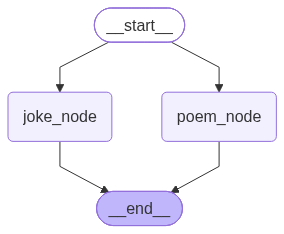

In [2]:
# 示例：两个 LLM 节点并行执行（标准格式）
# 标准 LLM 节点格式：读完整历史 state["messages"]，返回 {"messages": [response]}
# 两个并行节点写同一个 key（messages）→ add_messages 按 id 去重合并，两条回复都保留

from dotenv import load_dotenv
from IPython.display import display
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from rich import print as rprint

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled",
        },
    },
)


class ChatState(MessagesState):
    topic: str


def joke_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」讲一个笑话")]
    )
    response.name = "joke"           # 用 name 标记角色，便于区分并行节点的输出
    return {"messages": [response]}  # 标准格式：返回消息增量，走 add_messages 合并


def poem_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」写一首诗")]
    )
    response.name = "poem"
    return {"messages": [response]}


builder = StateGraph(state_schema=ChatState)
builder.add_node("joke_node", joke_node)
builder.add_node("poem_node", poem_node)
builder.add_edge(START, "joke_node")
builder.add_edge(START, "poem_node")
builder.add_edge("joke_node", END)
builder.add_edge("poem_node", END)

graph = builder.compile()
result = graph.invoke({
    "topic": "猫",
    "messages": [HumanMessage(content="请围绕这个主题展示你的才华")],
})
rprint(result)

# 显示图结构：两条静态边从 START 并行出发
display(graph)

## 1.2 条件分支

与静态分支不同，条件分支的**下游节点由运行时函数决定**：节点执行完后，LangGraph 调用一个**路由函数**读取 State，根据返回值从映射表里选出下一个节点。

+ 定义：路由函数 `(state) -> str`，返回值对应映射表里的 key，决定下一跳
+ 特点：
    - 下游候选集合在编译时通过映射表确定
    - **运行时**才决定走哪条边（路由函数读 State 判断）
    - 一个来源可以同时有多条条件边（多目标分支）
+ 与静态分支对比：
    - 静态分支（并行分支）：所有下游**同时**执行，运行前就确定
    - 条件分支：候选下游**二选一**，必须等路由函数跑完才知道去向
+ 核心判断：路由函数的返回值决定下游 -> 条件分支
+ 代码：`add_conditional_edges(源节点, 路由函数, {key: 目标节点})`

```python
# 三个参数：从哪个节点出发、路由函数、返回值 → 目标节点 的映射表
builder.add_conditional_edges("a", route, {"x": "b", "y": "c"})
```

**路由函数参数说明**：

- 签名：`def route(state) -> str`，与 Node 一样，第一个参数是**完整 State 快照**，按 key 读取任何需要的字段（全局 State、或私有 schema 中声明的同名 key），据此判断走向
- 返回值：必须是映射表的 **key**（字符串）；返回值不在映射表里会直接报错
- 变体：
    - 返回 `list[str]` → 同时走向**多个**目标（条件多分支）
    - 返回 `Command(goto=..., update=...)` → 边与 State 更新同时完成（`Command` 从 `langgraph.types` 导入，第 3 节详解）
- 调用时机：源节点执行完后、下一个 super-step 调度时调用；同一个路由函数每次执行都可能返回不同结果

条件分支是 LangGraph 最重要的控制流结构之一：本章第 2 节的循环（写诗 → 检查 → 重写）和第 2 章 3.1.2 的 plan → route → plan/answer 都是它实现的；ReAct 的「思考 → 行动 → 观察」循环同理。

下面给出与并行分支相同主题（主题创作）的条件分支案例。

[('joke', '好的，那我开始了：\n\n---\n\n一只猫走进了一家酒吧，跳上吧')]


[('poem', '## 《猫的驯养术》\n\n我们交换了语言的失落，\n在它琥珀色的')]


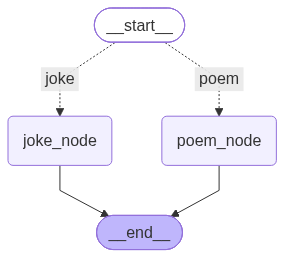

In [3]:
# 示例：条件分支 —— 同一组节点，运行时按 kind 选择走哪条边
# 与并行分支对比：并行是两条都跑，条件是根据 State 二选一

from dotenv import load_dotenv
from IPython.display import display
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from rich import print as rprint

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled",
        },
    },
)


class ChatState(MessagesState):
    topic: str
    kind: str   # "joke" | "poem"，路由函数根据它选择下游


def joke_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」讲一个笑话")]
    )
    response.name = "joke"
    return {"messages": [response]}


def poem_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」写一首诗")]
    )
    response.name = "poem"
    return {"messages": [response]}


# 路由函数：读 State，返回映射表的 key
def route(state: ChatState) -> str:
    return state["kind"]


builder = StateGraph(state_schema=ChatState)
builder.add_node("joke_node", joke_node)
builder.add_node("poem_node", poem_node)
# 条件边：直接从 START 出发，运行时根据 route 的返回值选择下游
# path_map 显式命名：路由函数返回值 → 目标节点 的映射表
builder.add_conditional_edges(START, route, path_map={"joke": "joke_node", "poem": "poem_node"})
builder.add_edge("joke_node", END)
builder.add_edge("poem_node", END)

graph = builder.compile()

# 同一组节点，两次 invoke 走不同路径
result = graph.invoke({"topic": "猫", "kind": "joke", "messages": [HumanMessage(content="请开始表演")]})
rprint([(m.name, m.content[:30]) for m in result["messages"] if m.name])

result = graph.invoke({"topic": "猫", "kind": "poem", "messages": [HumanMessage(content="请开始表演")]})
rprint([(m.name, m.content[:30]) for m in result["messages"] if m.name])

# 显示图结构：条件边从 START 出发，二选一
display(graph)

下面把条件分支扩展到**三个目标**：在主题创作中新增「国歌」节点，路由函数根据 `kind` 三选一。

[('joke', '好的，灯光就位，话筒试音——（清嗓子）\n\n**《猫的报恩》*')]


[('poem', '## 《猫》\n\n它从不曾真正睡着，\n随时预备着告别与重逢。\n')]


[('anthem', '# 猫之国歌\n\n*庄严、自豪地*\n\n---\n\n**第一段**')]


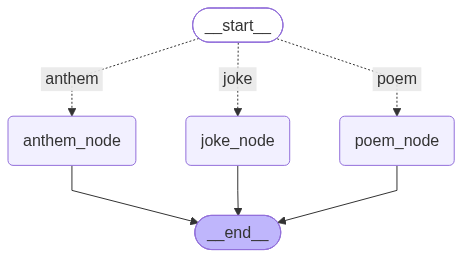

In [4]:
# 示例：条件分支三选一 —— 路由到国歌节点
# 与二选一相比只多了一个候选节点和一条映射项，路由函数不变

from dotenv import load_dotenv
from IPython.display import display
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from rich import print as rprint

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled",
        },
    },
)


class ChatState(MessagesState):
    topic: str
    kind: str   # "joke" | "poem" | "anthem"


def joke_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」讲一个笑话")]
    )
    response.name = "joke"
    return {"messages": [response]}


def poem_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」写一首诗")]
    )
    response.name = "poem"
    return {"messages": [response]}


# 新增的国歌节点：与 joke / poem 完全同构，只是提示词和 name 不同
def anthem_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」创作一首国歌")]
    )
    response.name = "anthem"
    return {"messages": [response]}


def route(state: ChatState) -> str:
    return state["kind"]


builder = StateGraph(state_schema=ChatState)
builder.add_node("joke_node", joke_node)
builder.add_node("poem_node", poem_node)
builder.add_node("anthem_node", anthem_node)
# 三选一：路由函数返回值决定走 joke / poem / anthem 中的哪条
builder.add_conditional_edges(START, route, path_map={
    "joke": "joke_node",
    "poem": "poem_node",
    "anthem": "anthem_node",
})
builder.add_edge("joke_node", END)
builder.add_edge("poem_node", END)
builder.add_edge("anthem_node", END)

graph = builder.compile()

# 同一组节点，三种 kind 各走一条路径
for kind in ["joke", "poem", "anthem"]:
    result = graph.invoke({"topic": "猫", "kind": kind, "messages": [HumanMessage(content="请开始表演")]})
    rprint([(m.name, m.content[:30]) for m in result["messages"] if m.name])

# 显示图结构：条件边从 START 出发，三选一
display(graph)

路由函数不仅支持**三选一**（返回单个 key），还可以返回 `list[str]` **同时走向多个目标**——三选一 / 三选二 / 三选三，都由同一个映射表决定：

| 路由返回值 | 效果 | 对应写法 |
|---|---|---|
| `"joke"` | 3 选 1：只走一个节点 | 返回单个字符串 |
| `["joke", "poem"]` | 3 选 2：两个节点**同一 super-step 并行**执行 | 返回字符串列表 |
| `["joke", "poem", "anthem"]` | 3 选 3：三个节点全部执行（等价于并行分支的 `add_edge` 写法） | 返回完整列表 |

注意：多目标并行执行时，`messages` 由 `add_messages` 按**完成顺序**合并——谁先返回谁在前，顺序不保证（见下方输出）。

请求 ['joke'] -> 实际执行: ['joke']
请求 ['joke', 'poem'] -> 实际执行: ['joke', 'poem']
请求 ['joke', 'poem', 'anthem'] -> 实际执行: ['anthem', 'joke', 'poem']


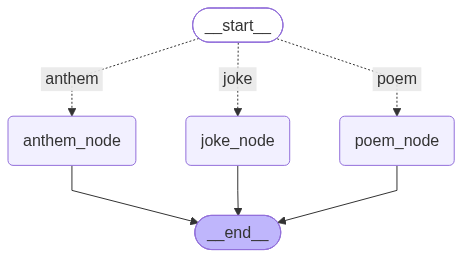

In [5]:
# 示例：3 选 1 / 3 选 2 / 3 选 3 —— 路由函数返回 list[str] 同时走向多个目标
# 与上一个案例的区别：kinds 是列表，route_multi 原样返回它

from dotenv import load_dotenv
from IPython.display import display
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from rich import print as rprint

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled",
        },
    },
)


class ChatState(MessagesState):
    topic: str
    kinds: list[str]   # 需要哪几个就放哪几个：["joke"] / ["joke","poem"] / 全部


def joke_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」讲一个笑话")]
    )
    response.name = "joke"
    return {"messages": [response]}


def poem_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」写一首诗")]
    )
    response.name = "poem"
    return {"messages": [response]}


def anthem_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」创作一首国歌")]
    )
    response.name = "anthem"
    return {"messages": [response]}


# 路由函数返回 list[str]：列表里的每个 key 都对应一个目标节点
def route_multi(state: ChatState) -> list[str]:
    return state["kinds"]


builder = StateGraph(state_schema=ChatState)
builder.add_node("joke_node", joke_node)
builder.add_node("poem_node", poem_node)
builder.add_node("anthem_node", anthem_node)
# 同一个映射表：单个字符串走一条，列表同时走多条
builder.add_conditional_edges(START, route_multi, path_map={
    "joke": "joke_node",
    "poem": "poem_node",
    "anthem": "anthem_node",
})
builder.add_edge("joke_node", END)
builder.add_edge("poem_node", END)
builder.add_edge("anthem_node", END)

graph = builder.compile()

# 3 选 1 / 3 选 2 / 3 选 3
for kinds in (["joke"], ["joke", "poem"], ["joke", "poem", "anthem"]):
    result = graph.invoke({"topic": "猫", "kinds": kinds, "messages": [HumanMessage(content="请开始表演")]})
    names = [m.name for m in result["messages"] if m.name]
    print(f"请求 {kinds} -> 实际执行: {names}")

# 显示图结构：条件边从 START 出发，三路候选，运行时可同时走多条
display(graph)

## 1.3 动态分支（Send API）

前两种分支的下游集合都在**编译期**确定。但有些场景编译期根本不知道下游有几个：比如「把任务拆成 N 个子任务并行处理」，N 是运行时才知道的。

`Send` 解决这个问题：Node 返回 `Command(goto=[Send(目标节点, 数据), ...])`，在**运行时动态创建并行任务**（map-reduce 的 map 部分）。每个 Send 相当于「向目标节点再投递一份输入」：

- `Send(node, payload)`：向 `node` 投递 `payload`，`payload` 会与当前 State 合并，成为该 node 的一次输入
- 返回几个 `Send`，目标节点就**并行**执行几次
- `Send` 从 `langgraph.types` 导入（与 `Command` 同源）

下面演示：planner 运行时把 3 个任务分发给 worker，worker 并行处理，结果用 reducer 汇总（纯 Python，不依赖 LLM）。

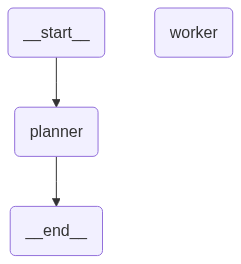

{'tasks': ['a', 'b', 'c'], 'results': ['处理完成: a', '处理完成: b', '处理完成: c']}


In [7]:
# 示例：Send 动态分支 —— planner 运行时把 N 个任务分发给 worker 并行处理
# 与静态分支的区别：并行任务的数量（3 个 worker 实例）是运行时由 planner 决定的

from operator import add
from typing import Annotated, TypedDict

from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, Send
from IPython.display import display


class SendState(TypedDict):
    tasks: list[str]  # 待处理任务
    results: Annotated[list[str], add]  # worker 结果，reducer 汇总


def planner(state: SendState) -> Command:
    # 每个任务向 worker 投递一份输入；worker 会并行执行 3 次
    return Command(goto=[Send("worker", {"task": t}) for t in state["tasks"]])


def worker(state) -> dict:
    # Send 的 payload 已合并进本次输入的 State，直接读 task
    return {"results": [f"处理完成: {state['task']}"]}


builder = StateGraph(state_schema=SendState)
builder.add_node("planner", planner)
builder.add_node("worker", worker)
builder.add_edge(START, "planner")
builder.add_edge("planner", END)  # planner 发完任务就结束自己的路径
builder.add_edge("worker", END)  # 每个 worker 实例结束后各自走向 END

graph = builder.compile()
display(graph)


print(graph.invoke({"tasks": ["a", "b", "c"], "results": []}))
# {'tasks': ['a', 'b', 'c'], 'results': ['处理完成: a', '处理完成: b', '处理完成: c']}

## 1.4 Defer 节点：并行分支的汇合点

`add_node(..., defer=True)`：让节点**推迟到调度器没有其它非 defer 工作可做时**再执行（`defer` 是 `StateNodeSpec` 上的参数，从 v0.6 起支持）。

- 适用场景：并行分支的**汇合点**（map-reduce、共识、多 agent 汇总）——聚合节点要等所有分支的结果都落地后再跑
- 语义：
  - defer 只是"推迟到无其它非 defer 工作"，**不是**"等所有祖先节点"；节点仍可能执行多次
  - 想让某个节点只在指定前提满足时跑，应显式用条件边 / `Command(goto=...)` 控制
- 对比（下面案例演示）：

| 写法 | 行为 |
|---|---|
| `add_node("aggregate", aggregate)` | 与并行分支**同一 super-step** 执行，读到的 State 里**没有**分支结果 |
| `add_node("aggregate", aggregate, defer=True)` | 分支先跑完（super-step 1），聚合节点在后续 super-step 执行，能看到**全部**结果 |

下面用主题创作演示：joke / poem 并行，聚合节点用 defer 等到两条回复都落地后再统计。

[aggregate] 执行时看到的 AI 回复: ['joke', 'poem']


共收到 2 条创作: ['joke', 'poem']


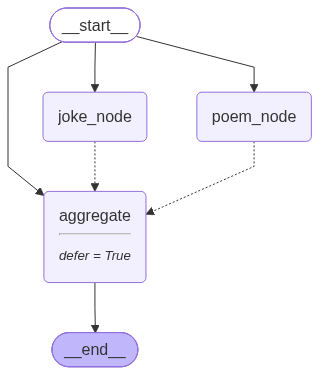

In [8]:
# 示例：Defer 节点 —— 聚合节点推迟到并行分支全部完成后再执行
# 对比：不加 defer 时，aggregate 与 joke/poem 同一 super-step 并行，读不到分支结果

from dotenv import load_dotenv
from IPython.display import display
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from rich import print as rprint

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled",
        },
    },
)


class ChatState(MessagesState):
    topic: str
    summary: str


def joke_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」讲一个笑话")]
    )
    response.name = "joke"
    return {"messages": [response]}


def poem_node(state: ChatState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content=f"根据主题「{state['topic']}」写一首诗")]
    )
    response.name = "poem"
    return {"messages": [response]}


# 聚合节点：defer=True → 推迟到没有其它非 defer 工作可做时才执行
def aggregate(state: ChatState) -> dict:
    names = [m.name for m in state["messages"] if m.name]
    print(f"[aggregate] 执行时看到的 AI 回复: {names}")
    return {"summary": f"共收到 {len(names)} 条创作: {names}"}


builder = StateGraph(state_schema=ChatState)
builder.add_node("joke_node", joke_node)
builder.add_node("poem_node", poem_node)
builder.add_node("aggregate", aggregate, defer=True)   # ← defer 节点
builder.add_edge(START, "joke_node")
builder.add_edge(START, "poem_node")
builder.add_edge(START, "aggregate")   # aggregate 也被 START 触发，但 defer 推迟执行
builder.add_edge("aggregate", END)

graph = builder.compile()

result = graph.invoke({"topic": "猫", "messages": [HumanMessage(content="请开始表演")]})
rprint(result["summary"])
# 输出示例: 共收到 2 条创作: ['joke', 'poem']   ← 两条并行回复都已落地

# 显示图结构：三条边从 START 出发，aggregate 是 defer 节点
display(graph)

# 2. 循环结构

循环是 LangGraph 最核心的能力：**边可以指回上游节点**，让 Graph 反复执行，直到条件边放行到 END。ReAct（思考 → 行动 → 观察 → 再思考）、生成-检查-重写都是循环。

两个关键点：

- 循环**必须**配合条件边：否则图会一直转下去。LangGraph 用 **recursion_limit** 兜底（默认 25 步），超过就抛 `GraphRecursionError`
- 每转一圈 State 都保留：`add_messages`、计数器 reducer 让 State 随循环累积——这是循环「越跑越接近目标」的前提

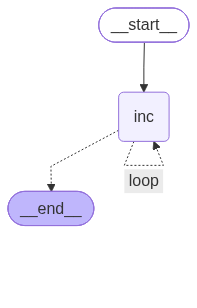

第 0 圈
第 1 圈
第 2 圈
{'count': 3}
第 0 圈
第 1 圈
第 2 圈
第 3 圈
第 4 圈
第 5 圈
第 6 圈
第 7 圈
第 8 圈
第 9 圈
触发了防死循环保护: Recursion limit of 10 reached without hitting a stop conditi


In [11]:
# 示例：计数器循环 —— 转 3 圈自动退出（纯 Python，不依赖 LLM）

from operator import add
from typing import Annotated, TypedDict

from langgraph.errors import GraphRecursionError
from langgraph.graph import END, START, StateGraph
from IPython.display import display

class LoopState(TypedDict):
    count: Annotated[int, add]


def inc(state: LoopState) -> dict:
    print(f"第 {state['count']} 圈")
    return {"count": 1}


def route(state: LoopState) -> str:
    return "loop" if state["count"] < 3 else END   # 满 3 圈放行到 END


builder = StateGraph(state_schema=LoopState)
builder.add_node("inc", inc)
builder.add_edge(START, "inc")
# 循环的关键：条件边的映射把 inc 指回自己；END 也放进映射表，route 返回 END 时直接结束
builder.add_conditional_edges("inc", route, {"loop": "inc", END: END})

graph = builder.compile()
display(graph)
print(graph.invoke({"count": 0}))
# 第 0 圈
# 第 1 圈
# 第 2 圈
# {'count': 3}


# recursion_limit 兜底：故意让循环永不退出，验证防死循环保护（默认上限 25 步）
def always_loop(state: LoopState) -> str:
    return "loop"


builder2 = StateGraph(state_schema=LoopState)
builder2.add_node("inc", inc)
builder2.add_edge(START, "inc")
builder2.add_conditional_edges("inc", always_loop, {"loop": "inc"})

try:
    builder2.compile().invoke({"count": 0}, config={"recursion_limit": 10})
except GraphRecursionError as e:
    print("触发了防死循环保护:", str(e)[:60])

In [13]:
# 示例：LLM 自纠错循环 —— 写诗直到包含「月亮」，不合格就重写

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from rich import print as rprint

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled",
        },
    },
)


class PoemState(MessagesState):
    ok: bool


def write_poem(state: PoemState) -> dict:
    response = model.invoke(
        state["messages"] + [HumanMessage(content="写一首描述太阳或月亮的短诗")]
    )
    return {"messages": [response]}


def check(state: PoemState) -> dict:
    last = state["messages"][-1]
    ok = "月亮" in (last.content or "")
    print(f"检查: 诗中{'包含' if ok else '不含'}月亮")
    return {"ok": ok}


def route(state: PoemState) -> str:
    return "finish" if state["ok"] else "write_poem"   # 不合格 → 指回写诗节点重写


def finish(state: PoemState) -> dict:
    return {}


builder = StateGraph(state_schema=PoemState)
builder.add_node("write_poem", write_poem)
builder.add_node("check", check)
builder.add_node("finish", finish)
builder.add_edge(START, "write_poem")
builder.add_edge("write_poem", "check")
# 循环的关键：check 的条件边把 write_poem 指回自己，同时保留通往 finish 的分支
builder.add_conditional_edges("check", route, {"write_poem": "write_poem", "finish": "finish"})
builder.add_edge("finish", END)

result = builder.compile().invoke({"messages": [HumanMessage(content="开始")]})
rprint(result["messages"][-1].content)

检查: 诗中不含月亮
检查: 诗中不含月亮
检查: 诗中不含月亮
检查: 诗中包含月亮


## 《日月》

太阳是一枚烧红的印章，
每天按时盖在天幕上。
月亮是未干的印泥，
夜夜重新涂抹，
让黎明不至于太过锋利。



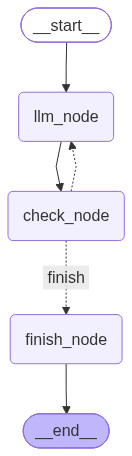

{
    'messages': [
        HumanMessage(
            content='请写一段简短文字，主题从金融、股票、摄影、天气、运动中选择一个',
            additional_kwargs={},
            response_metadata={},
            id='b1d4c138-d2aa-42d9-83db-24c8fec1437c'
        ),
        AIMessage(
            content='**天气**  \n凌晨五点，窗外的天空像湿透的宣纸，墨色晕染到天际线。雨点敲在玻璃上，节奏细密如旧打字机。我站在阳台上，看雨水把整座城市泡成一杯凉透的绿茶——高楼是沉在杯底的茶叶，路灯是浮起的柠檬片。等到七点，雨歇，云层撕开一道缝，光跌下来，砸在积水里，碎成一地温热的硬币。这样的早晨，适合原谅，适合重新爱上世界。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 115,
                    'prompt_tokens': 23,
                    'total_tokens': 138,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 23
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': '1bbd58ac-56a7-41f2-8edf-5df12cdc5170',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0252b-6e7e-71b3-be78-d6e61fc64831-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 23,
                'output_tokens': 115,
                'total_tokens': 138,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        HumanMessage(
            content='上一段文字包含不允许内容「天气」，请避开该主题重新写',
            additional_kwargs={},
            response_metadata={},
            id='da0313f2-cd4b-40f0-b6ea-93a6aeb78c8e'
        ),
        AIMessage(
            content='**摄影**  \n黄昏六点，我蹲在巷口的废品站前，取景框里是一台被雨水锈蚀的旧缝纫机。铁皮上斑驳的漆痕，在斜阳里竟然显出一种琥珀般的质地。旁边堆着几只褪色的搪瓷盆，边缘的缺口像被岁月咬过的齿痕。我按下快门时，一只橘猫踱进画面，慵懒地蹭过那台缝纫机，留下一撮绒毛在暮色里发光。取景框外的世界忽然塌陷，只剩光圈、焦距、与一帧凝固的安静。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 131,
                    'prompt_tokens': 157,
                    'total_tokens': 288,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 128,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 128,
                    'prompt_cache_miss_tokens': 29
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': 'd5addcfa-068f-4506-a4b3-7e5a9222acef',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0252b-7792-7380-b2d1-125b28af432d-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 157,
                'output_tokens': 131,
                'total_tokens': 288,
                'input_token_details': {'cache_read': 128},
                'output_token_details': {}
            }
        ),
        HumanMessage(
            content='上一段文字包含不允许内容「摄影」，请避开该主题重新写',
            additional_kwargs={},
            response_metadata={},
            id='801b27

In [ ]:
from operator import add
from typing import Annotated, Literal

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from rich import print as rprint

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled",
        },
    },
)


class ChatState(MessagesState):
    response: str
    stop: Literal["failure", "success"]


def llm_node(state: ChatState) -> dict:
    response = model.invoke(state["messages"])
    return {"response": response.content, "messages": [response]}


def check_node(state: ChatState) -> dict:
    words = ["股票", "摄影", "天气", "金融"]
    for word in words:
        if word in state["response"]:
            feedback = HumanMessage(
                content=f"上一段文字包含不允许内容「{word}」，请避开该主题重新写"
            )
            return {"stop": "failure", "messages": [feedback]}
    return {"stop": "success"}


def finish_node(state: ChatState) -> dict:
    return {}


def route_node(state: ChatState) -> str:
    return "llm_node" if state["stop"] == "failure" else "finish_node"


builder = StateGraph(state_schema=ChatState)
builder.add_node("llm_node", llm_node)
builder.add_node("check_node", check_node)
builder.add_node("finish_node", finish_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "check_node")
builder.add_conditional_edges(
    "check_node", route_node, {"llm_node": "llm_node", "finish_node": "finish_node"}
)
builder.add_edge("finish_node", END)

graph = builder.compile()
display(graph)

result = graph.invoke(
    {
        "check_count": 0,
        "messages": [
            HumanMessage(
                content="请写一段简短文字，主题从金融、股票、摄影、天气、运动中选择一个"
            )
        ],
    }
)
rprint(result)

# 3. Command：跳转与更新二合一

前面 Node 都是「返回 dict 更新 State」，跳转交给边。`Command` 让 Node 在返回时**同时**写 State 和指定下一跳：

- `Command(goto=..., update=...)`：`goto` 指定下一个节点（覆盖图上的边），`update` 是 State 更新（正常走 reducer 合并）
- 适用场景：agent 手写循环（模型输出 Command 直接指定下一步并携带数据）、「边跑边决定」的复杂控制流
- `Command` 从 `langgraph.types` 导入

> 等价关系：`return Command(goto="b", update={...})` ≈ `return {...}` + 条件边路由到 b。Command 把两件事合成一个返回值，让 Node 自己决定走向。

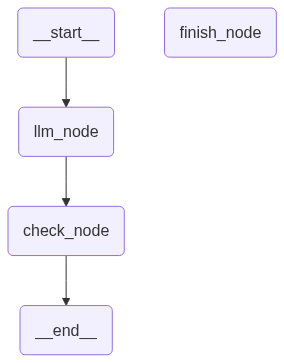

{
    'messages': [
        HumanMessage(
            content='请写一段简短文字，主题从金融、股票、摄影、天气、运动中选择一个',
            additional_kwargs={},
            response_metadata={},
            id='4b21f549-7c3d-444d-a363-e54768ea009b'
        ),
        AIMessage(
            content='你看，风又牵着柳絮走远了。\n\n午后的光斜过窗台，在木地板上摊开一张金箔的地图。我握着老旧的相机，等一个刚好经过的影子，把时间折叠成底片上的方寸。\n\n世间所有涨跌，其实都押在光线的恒常与无常之间。快门落下时，世界是无声的——像股市收盘后独自翻看K线的房间，像天气预报里永远失准的那场雨，又像发令枪响前，所有运动员胸腔里那只静止的鸟。\n\n最好的构图，往往是你根本来不及想，光就已经原谅了你的手抖。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 133,
                    'prompt_tokens': 23,
                    'total_tokens': 156,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 23
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': 'a3fd8c1a-a084-40eb-96d7-14d319565ea9',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a02533-9bc5-71d3-a1d1-b2594b2ecdd1-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 23,
                'output_tokens': 133,
                'total_tokens': 156,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        HumanMessage(
            content='上一段文字包含不允许内容「天气」，请避开该主题重新写',
            additional_kwargs={},
            response_metadata={},
            id='53f806bf-4fc3-4da7-93b4-f72ba7034df9'
        ),
        AIMessage(
            content='你看，风又牵着柳絮走远了。\n\n午后的光斜过窗台，在木地板上摊开一张金箔的地图。我握着老旧的相机，等一个刚好经过的影子，把时间折叠成底片上的方寸。\n\n世间所有涨跌，其实都押在光线的恒常与无常之间。快门落下时，世界是无声的——像股市收盘后独自翻看K线的房间，像跑步机上匀速前进却永远到不了终点的人，又像发令枪响前，所有运动员胸腔里那只静止的鸟。\n\n最好的构图，往往是你根本来不及想，光就已经原谅了你的手抖。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 135,
                    'prompt_tokens': 175,
                    'total_tokens': 310,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 175
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': '00651d8f-3f59-479d-9a5c-7abf6afc157f',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a02533-a4ed-70f2-81bf-93eb7b2aa23a-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 175,
                'output_tokens': 135,
                'total_tokens': 310,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ],
    'response': '你看，风又牵着柳絮走远了。\n\n午后的光斜过窗台，在木地板上摊开一张金箔的地图。我握着老旧的相机，等一个刚好经过的影子，把时间折叠成底片上的方寸。\n\n世间所有涨跌，其实都押在光线的恒常与无常之间。快门落下时，世界是无声的——像股市收盘后独自翻看K线的房间，像跑步机上匀速前进却永远到不了终点的人，又像发令枪响前，所有运动员胸腔里那只静止的鸟。\n

In [29]:
# 示例：Command —— check 节点同时更新 State 并指定下一跳（改写第 2 节的自纠错循环）
# 对比第 2 节案例：循环原来靠「stop 字段 + route 函数 + add_conditional_edges」实现，
# 这里 check_node 直接返回 Command(goto=..., update=...)：路由函数、stop 字段、条件边都不再需要

from dotenv import load_dotenv
from IPython.display import display
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.types import Command
from rich import print as rprint

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled",
        },
    },
)


class ChatState(MessagesState):
    response: str


def llm_node(state: ChatState) -> dict:
    response = model.invoke(state["messages"])
    return {"response": response.content, "messages": [response]}


def check_node(state: ChatState) -> Command:
    words = ["股票", "摄影", "天气", "金融"]
    for word in words:
        if word in state["response"]:
            feedback = HumanMessage(
                content=f"上一段文字包含不允许内容「{word}」，请避开该主题重新写"
            )
            # 不合格：Command 一步完成「更新 State（写回反馈）」+「指定下一跳（回 llm_node 重写）」
            return Command(goto="llm_node", update={"messages": [feedback]})
    # 合格：跳向 finish_node 收尾，无需再更新 State
    return Command(goto="finish_node")


def finish_node(state: ChatState) -> dict:
    return {}


builder = StateGraph(state_schema=ChatState)
builder.add_node("llm_node", llm_node)
builder.add_node("check_node", check_node)
builder.add_node("finish_node", finish_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "check_node")
# check_node 没有出边：走向完全由它返回的 Command.goto 决定（第 2 节的等价写法是条件边）
builder.add_edge("finish_node", END)

graph = builder.compile()
display(graph)

result = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="请写一段简短文字，主题从金融、股票、摄影、天气、运动中选择一个"
            )
        ],
    }
)
rprint(result)